# Rainfall Forecasting using Time Series Analysis

### Project Name
Rainfall Prediction using Time Series Forecasting

### Objective
To predict rainfall for the next 12 months using historical rainfall data.

# Business Problem

Rainfall prediction is important for agriculture, water resource management,
disaster prevention and weather forecasting.

This project predicts rainfall for the next one year using historical rainfall data.

# Project Goal

• Understand the rainfall dataset

• Clean the data

• Perform Exploratory Data Analysis

• Check Stationarity

• Build Time Series Model

• Forecast rainfall for next 12 months

• Evaluate Model

# Step 1 : Import Required Libraries

In this step, we import all the libraries required for data manipulation,
visualization, statistical analysis and time series forecasting.

In [1]:
# ==============================
# Import Required Libraries
# ==============================

import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time Series Visualization
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

# Stationarity Test
from statsmodels.tsa.stattools import adfuller

# Time Series Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# SARIMA Model
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Set plotting style
plt.style.use("ggplot")

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Step 2 : Load the Dataset

We load all three rainfall datasets.

- Monthly Total Rainfall
- Monthly Highest Daily Rainfall
- Monthly Number of Rainy Days

In [2]:
# ==============================
# Load Datasets
# ==============================

total = pd.read_csv("rainfall-monthly-total.csv")

highest = pd.read_csv("rainfall-monthly-highest-daily-total.csv")

rain_days = pd.read_csv("rainfall-monthly-number-of-rain-days.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


# Step 3 : View the Dataset

Display the first five rows of each dataset.

In [3]:
print("Monthly Total Rainfall")
display(total.head())

print("Highest Daily Rainfall")
display(highest.head())

print("Rainy Days")
display(rain_days.head())

Monthly Total Rainfall


,month,total_rainfall
0,1982-01,107.1
1,1982-02,27.8
2,1982-03,160.8
3,1982-04,157.0
4,1982-05,102.2


Highest Daily Rainfall


,month,maximum_rainfall_in_a_day
0,1982-01,36.5
1,1982-02,9.4
2,1982-03,61.7
3,1982-04,45.1
4,1982-05,33.0


Rainy Days


,month,no_of_rainy_days
0,1982-01,10
1,1982-02,5
2,1982-03,11
3,1982-04,14
4,1982-05,10


# Step 4 : Check Dataset Shape

The shape tells us the number of rows and columns present in each dataset.

In [4]:
print("Monthly Total Shape :", total.shape)

print("Highest Daily Shape :", highest.shape)

print("Rainy Days Shape :", rain_days.shape)

Monthly Total Shape : (462, 2)
Highest Daily Shape : (462, 2)
Rainy Days Shape : (462, 2)


# Step 5 : Check Column Names

Understanding column names is important before preprocessing.

In [5]:
print("Monthly Total Columns")
print(total.columns)

print()

print("Highest Daily Columns")
print(highest.columns)

print()

print("Rainy Days Columns")
print(rain_days.columns)

Monthly Total Columns
Index(['month', 'total_rainfall'], dtype='object')

Highest Daily Columns
Index(['month', 'maximum_rainfall_in_a_day'], dtype='object')

Rainy Days Columns
Index(['month', 'no_of_rainy_days'], dtype='object')


# Step 6 : Dataset Information

The info() function provides

- Number of rows
- Data types
- Missing values
- Memory usage

In [6]:
print("Monthly Total")

total.info()

print("\n")

print("Highest Daily")

highest.info()

print("\n")

print("Rainy Days")

rain_days.info()

Monthly Total
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   month           462 non-null    object 
 1   total_rainfall  462 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.3+ KB


Highest Daily
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 2 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      462 non-null    object 
 1   maximum_rainfall_in_a_day  462 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.3+ KB


Rainy Days
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   month             462 non-null    object

# Step 7 : Statistical Summary

The describe() function gives statistical information like

- Mean
- Median (50%)
- Standard Deviation
- Minimum
- Maximum

In [7]:
print("Monthly Total Rainfall")
display(total.describe())

print()

print("Highest Daily Rainfall")
display(highest.describe())

print()

print("Rainy Days")
display(rain_days.describe())

Monthly Total Rainfall


,total_rainfall
count,462.000000
mean,176.236580
std,113.296793
min,0.200000
25%,89.025000
50%,158.450000
75%,237.950000
max,765.900000



Highest Daily Rainfall


,maximum_rainfall_in_a_day
count,462.000000
mean,52.358225
std,35.685122
min,0.200000
25%,30.625000
50%,43.450000
75%,63.150000
max,216.200000



Rainy Days


,no_of_rainy_days
count,462.000000
mean,13.958874
std,4.947494
min,1.000000
25%,11.000000
50%,14.000000
75%,18.000000
max,27.000000


# Step 8 : Check Missing Values

Before building the forecasting model, we verify whether any missing values exist.

In [8]:
print("Monthly Total")

print(total.isnull().sum())

print()

print("Highest Daily")

print(highest.isnull().sum())

print()

print("Rainy Days")

print(rain_days.isnull().sum())

Monthly Total
month             0
total_rainfall    0
dtype: int64

Highest Daily
month                        0
maximum_rainfall_in_a_day    0
dtype: int64

Rainy Days
month               0
no_of_rainy_days    0
dtype: int64


# Step 9 : Check Duplicate Records

Duplicate records can affect forecasting performance.

In [9]:
print("Monthly Total :", total.duplicated().sum())

print("Highest Daily :", highest.duplicated().sum())

print("Rainy Days :", rain_days.duplicated().sum())

Monthly Total : 0
Highest Daily : 0
Rainy Days : 0


# Step 10 : Convert Month Column into Datetime

Time series models require the date column to be in datetime format.

In [10]:
total["month"] = pd.to_datetime(total["month"])

highest["month"] = pd.to_datetime(highest["month"])

rain_days["month"] = pd.to_datetime(rain_days["month"])

print(total.dtypes)

month             datetime64[ns]
total_rainfall           float64
dtype: object


# Step 11 : Merge the Three Datasets

The three datasets are merged using the common column **month**.

Final Dataset Columns

- Month
- Total Rainfall
- Highest Daily Rainfall
- Number of Rainy Days

In [11]:
df = pd.merge(total, highest, on="month")

df = pd.merge(df, rain_days, on="month")

display(df.head())

,month,total_rainfall,maximum_rainfall_in_a_day,no_of_rainy_days
0,1982-01-01,107.1,36.5,10
1,1982-02-01,27.8,9.4,5
2,1982-03-01,160.8,61.7,11
3,1982-04-01,157.0,45.1,14
4,1982-05-01,102.2,33.0,10


# Step 12 : Final Dataset Information

Let's verify the merged dataset.

In [12]:
print(df.shape)

display(df.head())

display(df.tail())

df.info()

(462, 4)


,month,total_rainfall,maximum_rainfall_in_a_day,no_of_rainy_days
0,1982-01-01,107.1,36.5,10
1,1982-02-01,27.8,9.4,5
2,1982-03-01,160.8,61.7,11
3,1982-04-01,157.0,45.1,14
4,1982-05-01,102.2,33.0,10


,month,total_rainfall,maximum_rainfall_in_a_day,no_of_rainy_days
457,2020-02-01,65.0,23.8,8
458,2020-03-01,108.8,47.4,8
459,2020-04-01,188.0,51.8,12
460,2020-05-01,255.6,53.8,16
461,2020-06-01,233.8,41.0,21


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      462 non-null    datetime64[ns]
 1   total_rainfall             462 non-null    float64       
 2   maximum_rainfall_in_a_day  462 non-null    float64       
 3   no_of_rainy_days           462 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 14.6 KB


In [13]:
df.to_csv("Rainfall_Final_Dataset.csv", index=False)

print("Merged dataset saved successfully.")

Merged dataset saved successfully.


# Data Cleaning & Exploratory Data Analysis (EDA)

# Step 14 : Check Missing Values Again

After merging the datasets, we verify whether any missing values are present.

In [14]:
# Check missing values

df.isnull().sum()

month                        0
total_rainfall               0
maximum_rainfall_in_a_day    0
no_of_rainy_days             0
dtype: int64

# Step 15 : Handle Missing Values

If any missing values are present, replace them with the median value.

Median is preferred because rainfall data may contain outliers.

In [15]:
# Fill missing values

df["total_rainfall"] = df["total_rainfall"].fillna(df["total_rainfall"].median())

df["maximum_rainfall_in_a_day"] = df["maximum_rainfall_in_a_day"].fillna(
    df["maximum_rainfall_in_a_day"].median())

df["no_of_rainy_days"] = df["no_of_rainy_days"].fillna(
    df["no_of_rainy_days"].median())

print("Missing values handled successfully.")

Missing values handled successfully.


# Step 16 : Check Duplicate Records

Duplicate rows can affect the forecasting model.

Remove duplicate rows if they exist.

In [16]:
print("Duplicate Rows :", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate Rows after removal :", df.duplicated().sum())

Duplicate Rows : 0
Duplicate Rows after removal : 0


# Step 17 : Set Month as Index

Time series models require the date column to be the dataframe index.

In [17]:
df = df.set_index("month")

df.head()

,total_rainfall,maximum_rainfall_in_a_day,no_of_rainy_days
month,,,
1982-01-01,107.1,36.5,10
1982-02-01,27.8,9.4,5
1982-03-01,160.8,61.7,11
1982-04-01,157.0,45.1,14
1982-05-01,102.2,33.0,10


# Step 18 : Feature Engineering

Extract useful date features for analysis.

In [18]:
df["Year"] = df.index.year
df["Month"] = df.index.month
df["Quarter"] = df.index.quarter

df.head()

,total_rainfall,maximum_rainfall_in_a_day,no_of_rainy_days,Year,Month,Quarter
month,,,,,,
1982-01-01,107.1,36.5,10,1982,1,1
1982-02-01,27.8,9.4,5,1982,2,1
1982-03-01,160.8,61.7,11,1982,3,1
1982-04-01,157.0,45.1,14,1982,4,2
1982-05-01,102.2,33.0,10,1982,5,2


# Step 19 : Statistical Summary

Display summary statistics of the cleaned dataset.

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_rainfall,462.0,176.236580,113.296793,0.2,89.025,158.45,237.95,765.9
maximum_rainfall_in_a_day,462.0,52.358225,35.685122,0.2,30.625,43.45,63.15,216.2
no_of_rainy_days,462.0,13.958874,4.947494,1.0,11.000,14.00,18.00,27.0
Year,462.0,2000.753247,11.127916,1982.0,1991.000,2001.00,2010.00,2020.0
Month,462.0,6.461039,3.455574,1.0,3.000,6.00,9.00,12.0
Quarter,462.0,2.487013,1.119170,1.0,1.000,2.00,3.00,4.0


# Step 20 : Correlation Analysis

Correlation helps identify relationships between numerical variables.

In [20]:
df.corr(numeric_only=True)

,total_rainfall,maximum_rainfall_in_a_day,no_of_rainy_days,Year,Month,Quarter
total_rainfall,1.000000,0.803289,0.702367,-0.038915,0.242420,0.234558
maximum_rainfall_in_a_day,0.803289,1.000000,0.410757,-0.074244,0.109052,0.104354
no_of_rainy_days,0.702367,0.410757,1.000000,0.065968,0.405732,0.413012
Year,-0.038915,-0.074244,0.065968,1.000000,-0.019543,-0.020114
Month,0.242420,0.109052,0.405732,-0.019543,1.000000,0.971622
Quarter,0.234558,0.104354,0.413012,-0.020114,0.971622,1.000000


# Step 21 : Correlation Heatmap

A heatmap visually represents the correlation matrix.

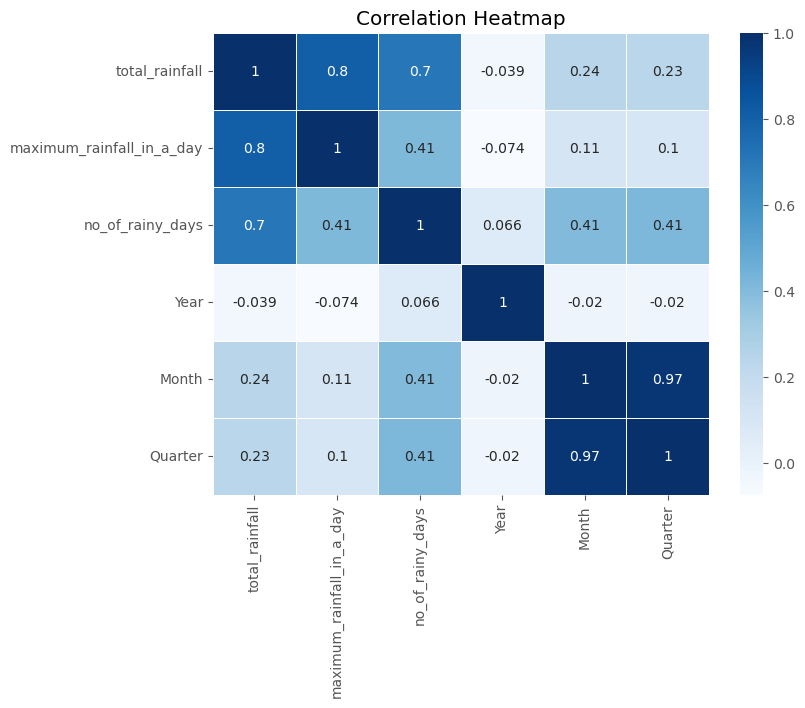

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Blues",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

# Step 22 : Histogram

The histogram shows the distribution of total rainfall.

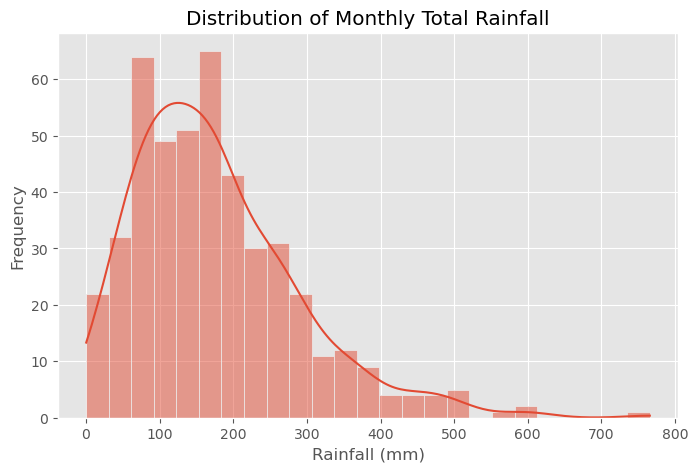

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df["total_rainfall"], bins=25, kde=True)

plt.title("Distribution of Monthly Total Rainfall")

plt.xlabel("Rainfall (mm)")

plt.ylabel("Frequency")

plt.show()

# Step 23 : Box Plot

The boxplot helps identify outliers.

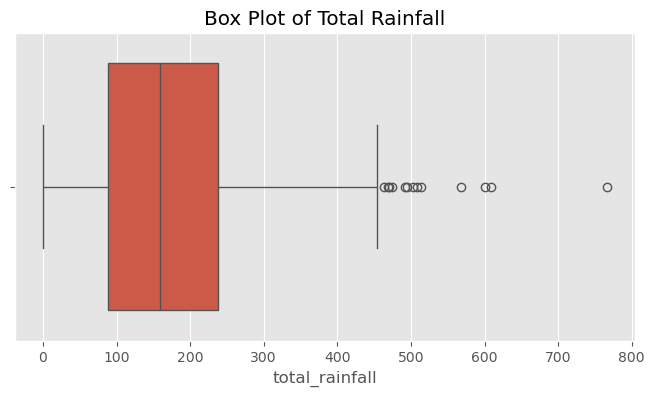

In [23]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["total_rainfall"])

plt.title("Box Plot of Total Rainfall")

plt.show()

# Step 24 : Monthly Rainfall Trend

Visualize rainfall over time.

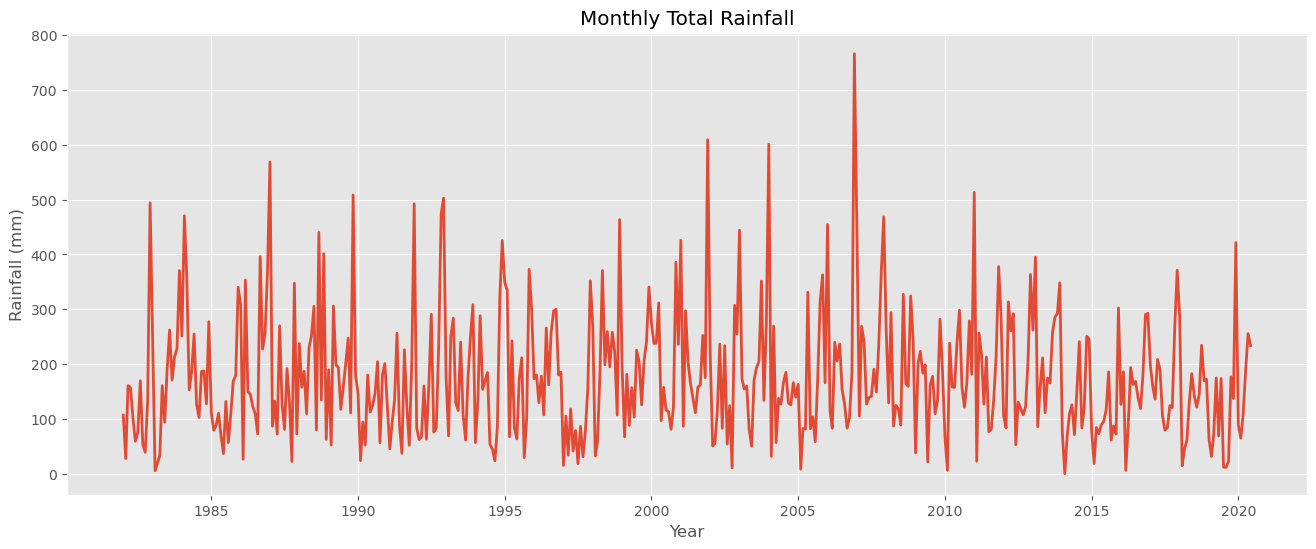

In [24]:
plt.figure(figsize=(16,6))

plt.plot(
    df.index,
    df["total_rainfall"],
    linewidth=2
)

plt.title("Monthly Total Rainfall")

plt.xlabel("Year")

plt.ylabel("Rainfall (mm)")

plt.grid(True)

plt.show()

# Step 25 : Highest Daily Rainfall Trend

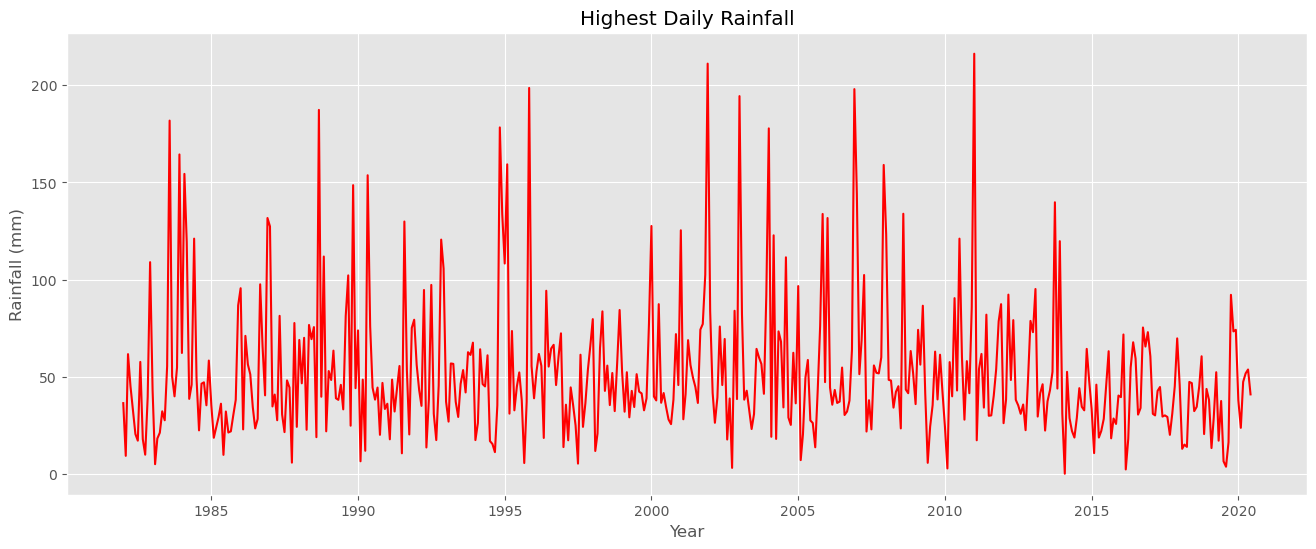

In [25]:
plt.figure(figsize=(16,6))

plt.plot(
    df.index,
    df["maximum_rainfall_in_a_day"],
    color="red"
)

plt.title("Highest Daily Rainfall")

plt.xlabel("Year")

plt.ylabel("Rainfall (mm)")

plt.grid(True)

plt.show()

# Step 26 : Rainy Days Trend

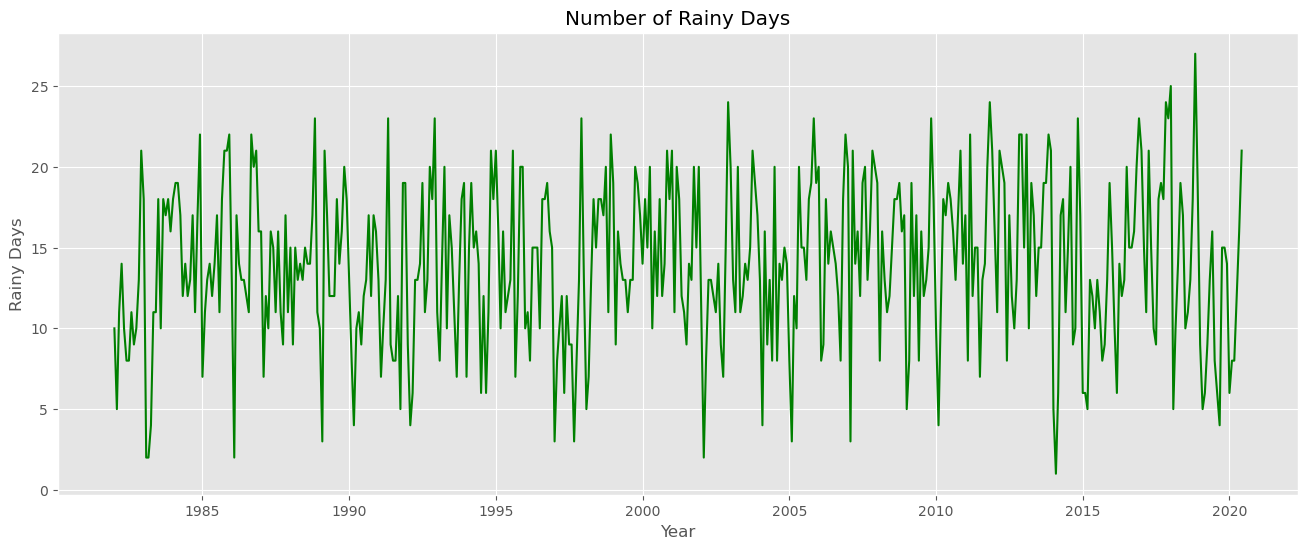

In [26]:
plt.figure(figsize=(16,6))

plt.plot(
    df.index,
    df["no_of_rainy_days"],
    color="green"
)

plt.title("Number of Rainy Days")

plt.xlabel("Year")

plt.ylabel("Rainy Days")

plt.grid(True)

plt.show()

# Step 27 : Average Monthly Rainfall

Find the average rainfall for each month.

In [27]:
monthly_avg = df.groupby("Month")["total_rainfall"].mean()

monthly_avg

Month
1     225.987179
2     104.735897
3     160.294872
4     153.017949
5     165.828205
6     134.287179
7     146.344737
8     147.052632
9     145.681579
10    161.350000
11    255.626316
12    317.613158
Name: total_rainfall, dtype: float64

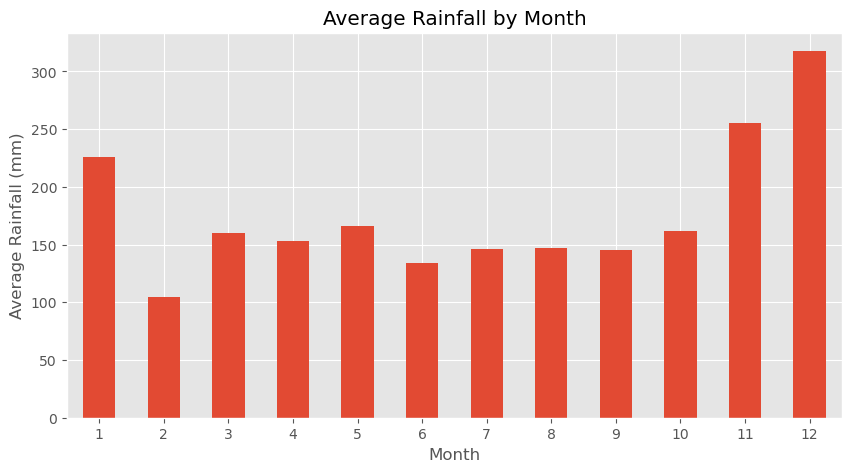

In [28]:
plt.figure(figsize=(10,5))

monthly_avg.plot(kind="bar")

plt.title("Average Rainfall by Month")

plt.xlabel("Month")

plt.ylabel("Average Rainfall (mm)")

plt.xticks(rotation=0)

plt.show()

# Step 28 : Average Yearly Rainfall

In [29]:
yearly_avg = df.groupby("Year")["total_rainfall"].mean()

yearly_avg.head()

Year
1982    131.808333
1983    166.141667
1984    223.891667
1985    123.658333
1986    211.341667
Name: total_rainfall, dtype: float64

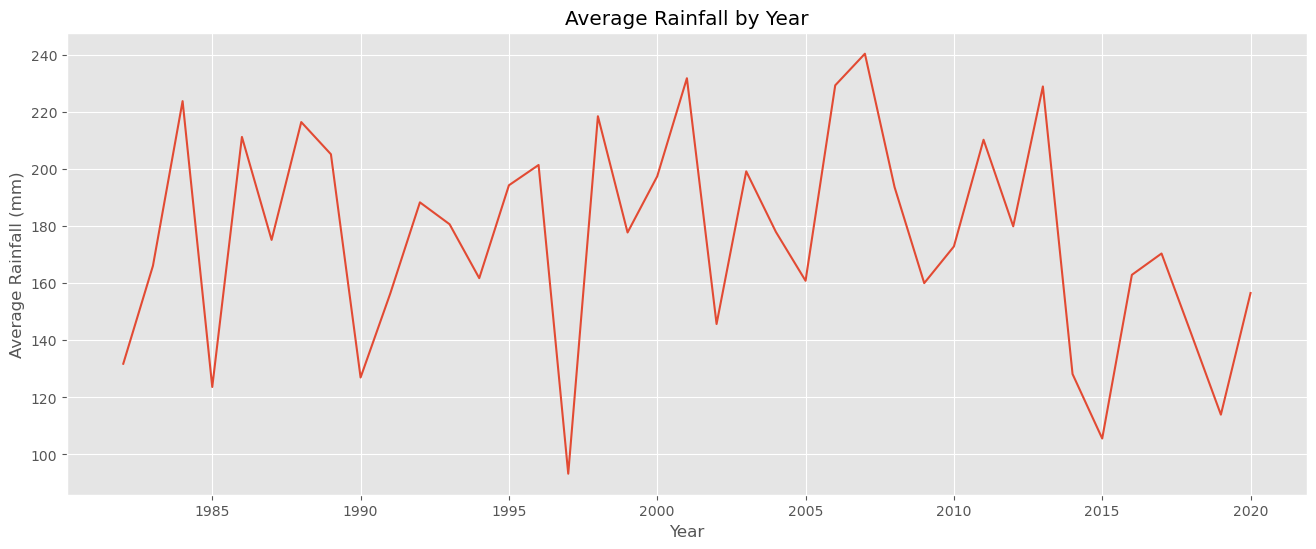

In [30]:
plt.figure(figsize=(16,6))

yearly_avg.plot()

plt.title("Average Rainfall by Year")

plt.xlabel("Year")

plt.ylabel("Average Rainfall (mm)")

plt.grid(True)

plt.show()

# Step 29 : Scatter Plot

Relationship between rainfall and rainy days.

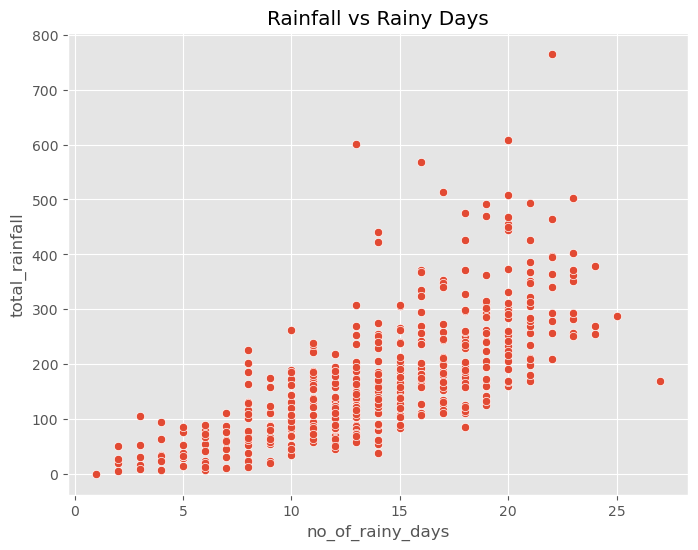

In [31]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="no_of_rainy_days",
    y="total_rainfall",
    data=df
)

plt.title("Rainfall vs Rainy Days")

plt.show()

# Step 30 : Pair Plot

Shows relationships between numerical features.

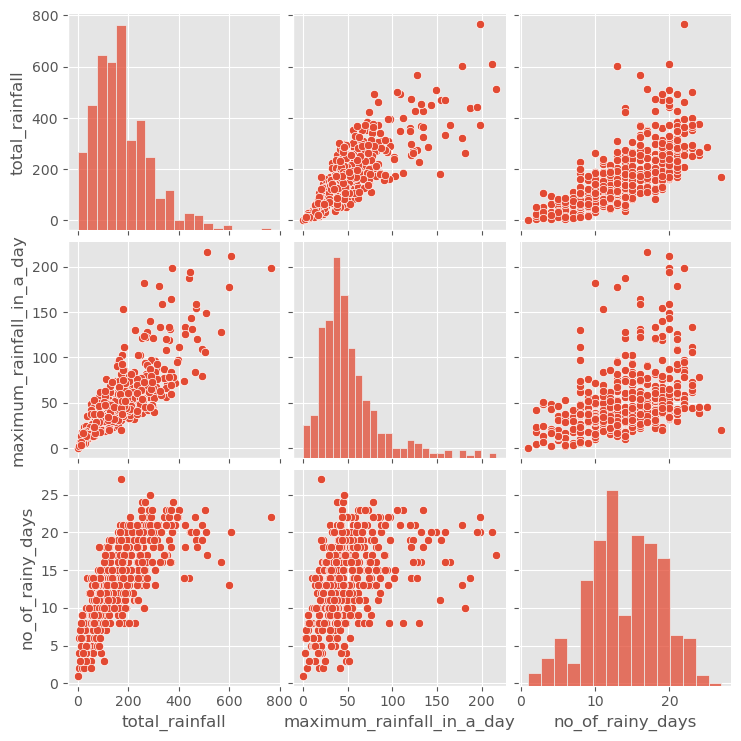

In [32]:
sns.pairplot(
    df[
        [
            "total_rainfall",
            "maximum_rainfall_in_a_day",
            "no_of_rainy_days"
        ]
    ]
)

plt.show()

# Step 31 : Insights from EDA

### Observations

- Monthly rainfall varies significantly over time.
- Some months experience very high rainfall.
- Rainy days generally increase with total rainfall.
- Seasonal patterns are visible.
- No major data quality issues remain after preprocessing.
- The data is suitable for time series forecasting.

In the next section, we will prepare the series for forecasting by checking stationarity, computing rolling statistics, performing the ADF test, visualizing seasonality, and creating ACF and PACF plots before building the SARIMA model.

# Time Series Analysis (Stationarity & Model Preparation)

# Step 32 : Prepare Time Series Data

For forecasting, we only need the **Monthly Total Rainfall** as the target variable.

This variable will be used to build the SARIMA model.

In [33]:
# Select Target Variable

ts = df["total_rainfall"]

display(ts.head())

print("Total Observations :", len(ts))

month
1982-01-01    107.1
1982-02-01     27.8
1982-03-01    160.8
1982-04-01    157.0
1982-05-01    102.2
Name: total_rainfall, dtype: float64

Total Observations : 462


# Step 33 : Visualize Time Series

Before forecasting, visualize the rainfall series to understand its trend and seasonality.

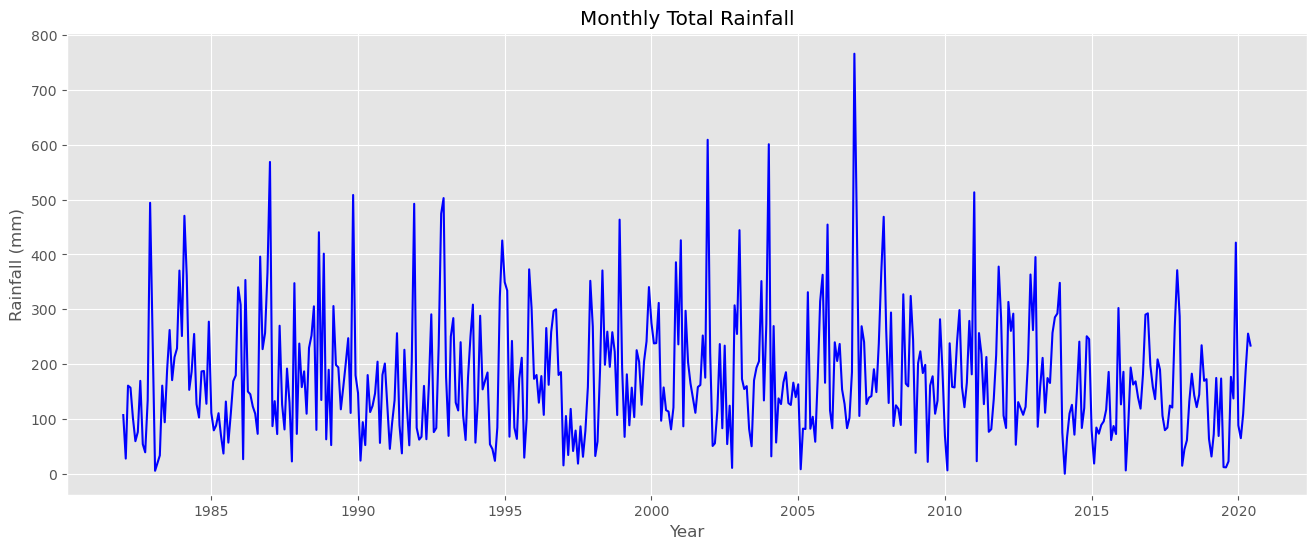

In [34]:
plt.figure(figsize=(16,6))

plt.plot(ts, color="blue")

plt.title("Monthly Total Rainfall")

plt.xlabel("Year")

plt.ylabel("Rainfall (mm)")

plt.grid(True)

plt.show()

# Step 34 : Rolling Mean and Rolling Standard Deviation

Rolling statistics help determine whether the time series is stationary.

If the rolling mean and rolling standard deviation remain relatively constant over time, the series is likely stationary.

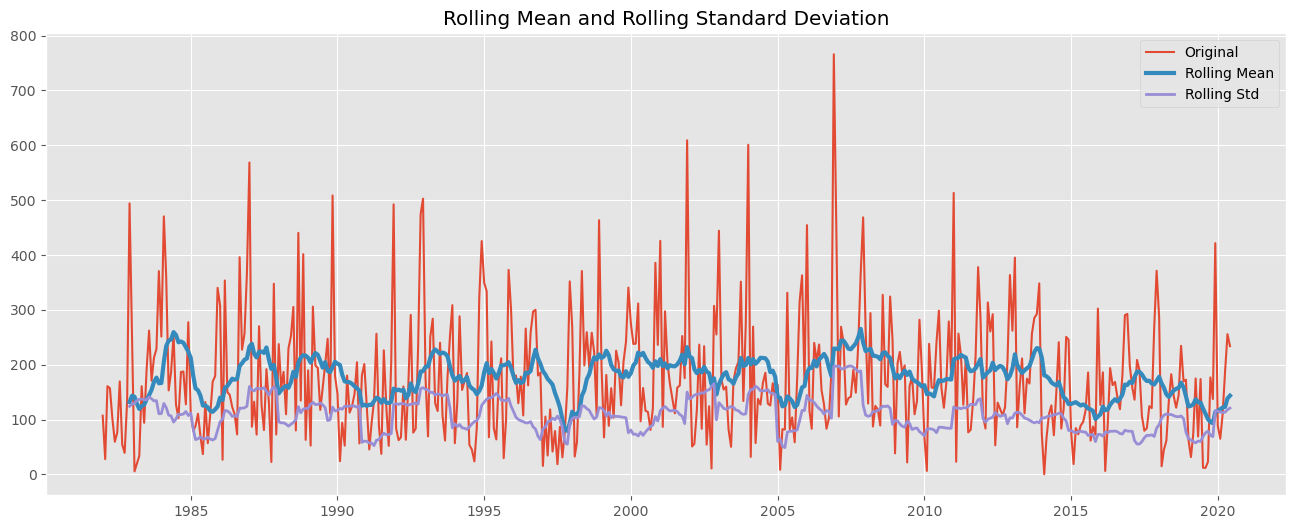

In [35]:
rolling_mean = ts.rolling(window=12).mean()

rolling_std = ts.rolling(window=12).std()

plt.figure(figsize=(16,6))

plt.plot(ts, label="Original")

plt.plot(rolling_mean, label="Rolling Mean", linewidth=3)

plt.plot(rolling_std, label="Rolling Std", linewidth=2)

plt.legend()

plt.title("Rolling Mean and Rolling Standard Deviation")

plt.show()

# Step 35 : Augmented Dickey-Fuller (ADF) Test

The ADF test checks whether the time series is stationary.

### Null Hypothesis (H₀)

The time series is **not stationary**.

### Alternative Hypothesis (H₁)

The time series is **stationary**.

### Decision Rule

- p-value < 0.05 → Reject H₀ → Stationary
- p-value ≥ 0.05 → Fail to Reject H₀ → Non-Stationary

In [36]:
result = adfuller(ts)

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print()

print("Critical Values")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic : -5.316803062036406
p-value : 5.05345668949158e-06

Critical Values
1% : -3.4450642060791097
5% : -2.868027634065253
10% : -2.5702256691640515


In [37]:
if result[1] < 0.05:
    print("Conclusion")
    print("The rainfall series is Stationary.")
else:
    print("Conclusion")
    print("The rainfall series is Non-Stationary.")

Conclusion
The rainfall series is Stationary.


# Step 36 : Seasonal Decomposition

Seasonal decomposition separates the series into

- Trend
- Seasonal
- Residual

This helps us understand the underlying structure of the rainfall data.

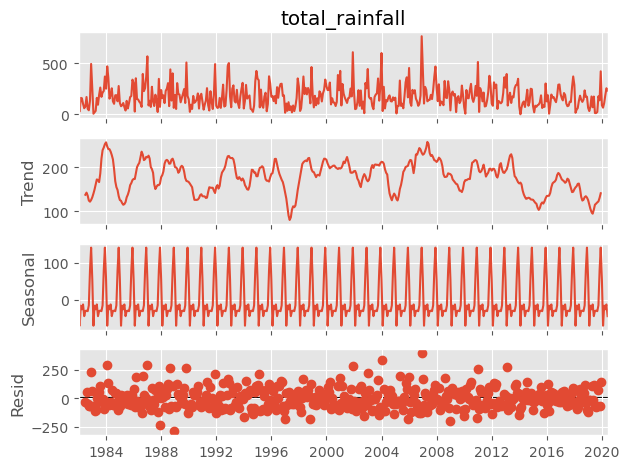

In [38]:
decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=12
)

decomposition.plot()

plt.show()

# Step 37 : Trend Component

The trend component represents the long-term movement in rainfall.

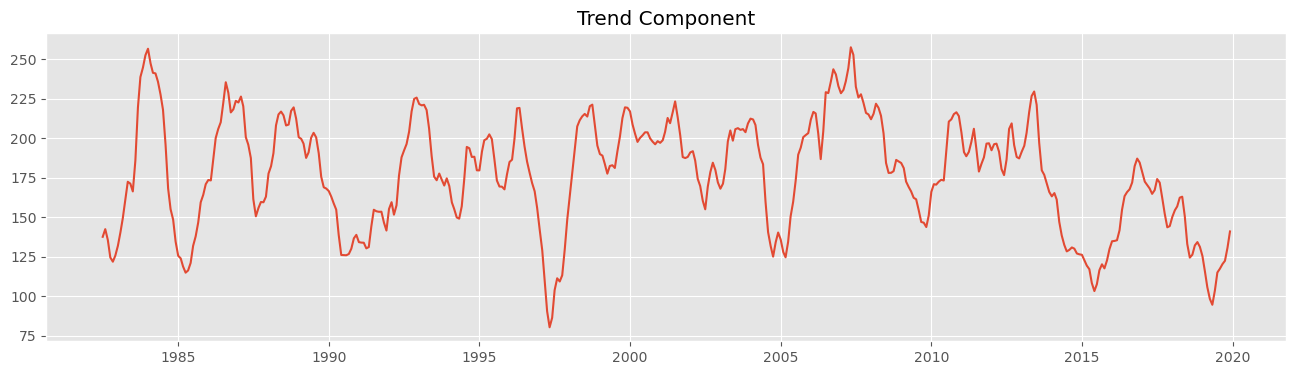

In [39]:
plt.figure(figsize=(16,4))

plt.plot(decomposition.trend)

plt.title("Trend Component")

plt.show()

# Step 38 : Seasonal Component

The seasonal component captures repeating yearly rainfall patterns.

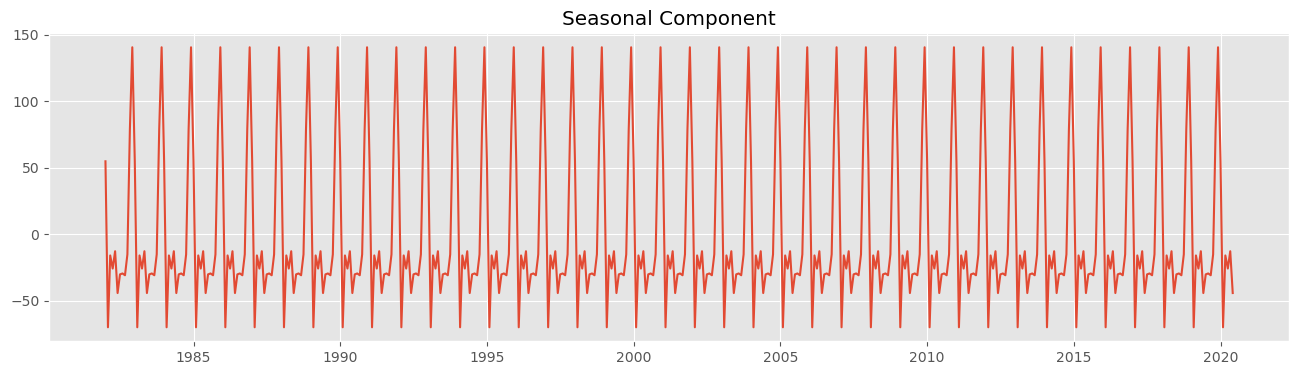

In [40]:
plt.figure(figsize=(16,4))

plt.plot(decomposition.seasonal)

plt.title("Seasonal Component")

plt.show()

# Step 39 : Residual Component

Residuals represent random variations remaining after removing trend and seasonality.

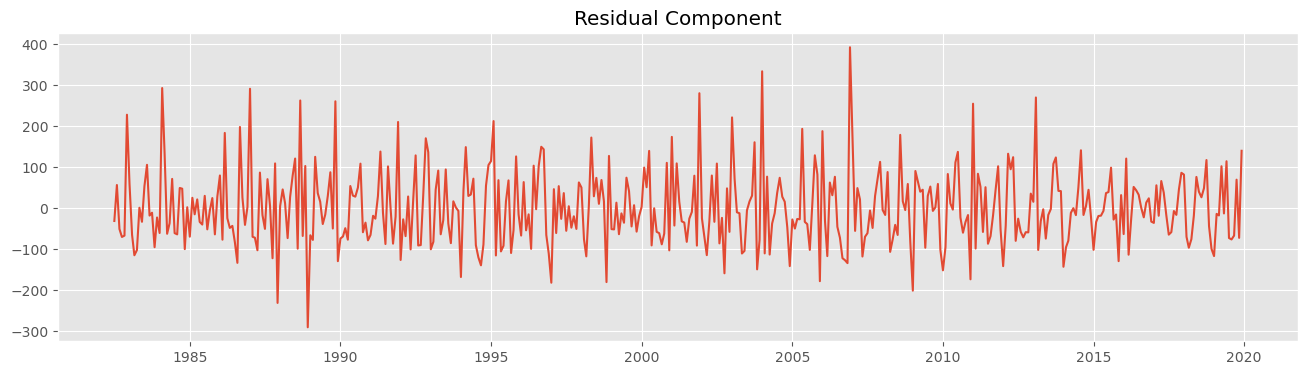

In [41]:
plt.figure(figsize=(16,4))

plt.plot(decomposition.resid)

plt.title("Residual Component")

plt.show()

# Step 40 : Autocorrelation Function (ACF)

The ACF plot helps identify the Moving Average (MA) order (q).

It shows how observations are correlated with previous values.

<Figure size 1000x500 with 0 Axes>

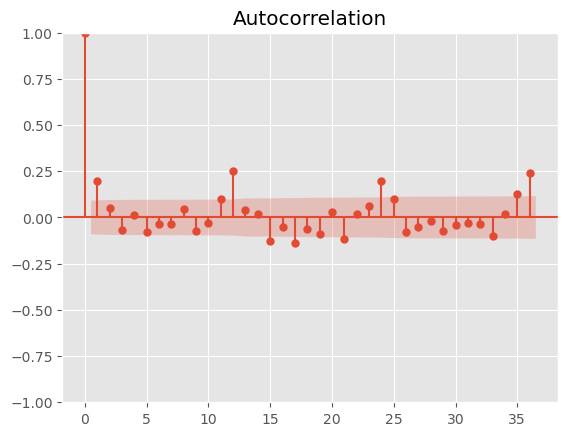

In [42]:
plt.figure(figsize=(10,5))

plot_acf(ts, lags=36)

plt.show()

# Step 41 : Partial Autocorrelation Function (PACF)

The PACF plot helps determine the AutoRegressive (AR) order (p).

<Figure size 1000x500 with 0 Axes>

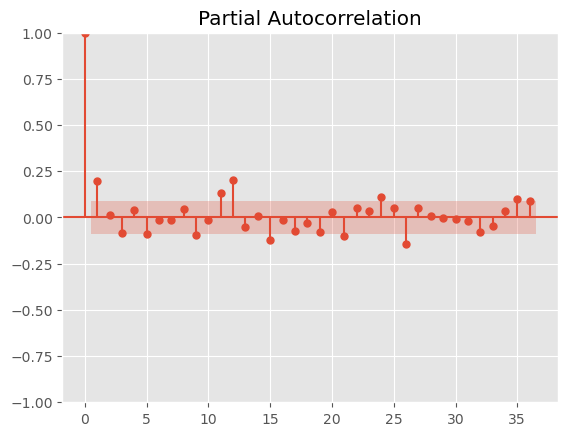

In [43]:
plt.figure(figsize=(10,5))

plot_pacf(
    ts,
    lags=36,
    method="ywm"
)

plt.show()

# Step 42 : Train-Test Split

To evaluate forecasting performance, split the data into training and testing sets.

- Training Data → 80%
- Testing Data → 20%

In [44]:
train_size = int(len(ts) * 0.80)

train = ts[:train_size]

test = ts[train_size:]

print("Training Samples :", len(train))

print("Testing Samples :", len(test))

Training Samples : 369
Testing Samples : 93


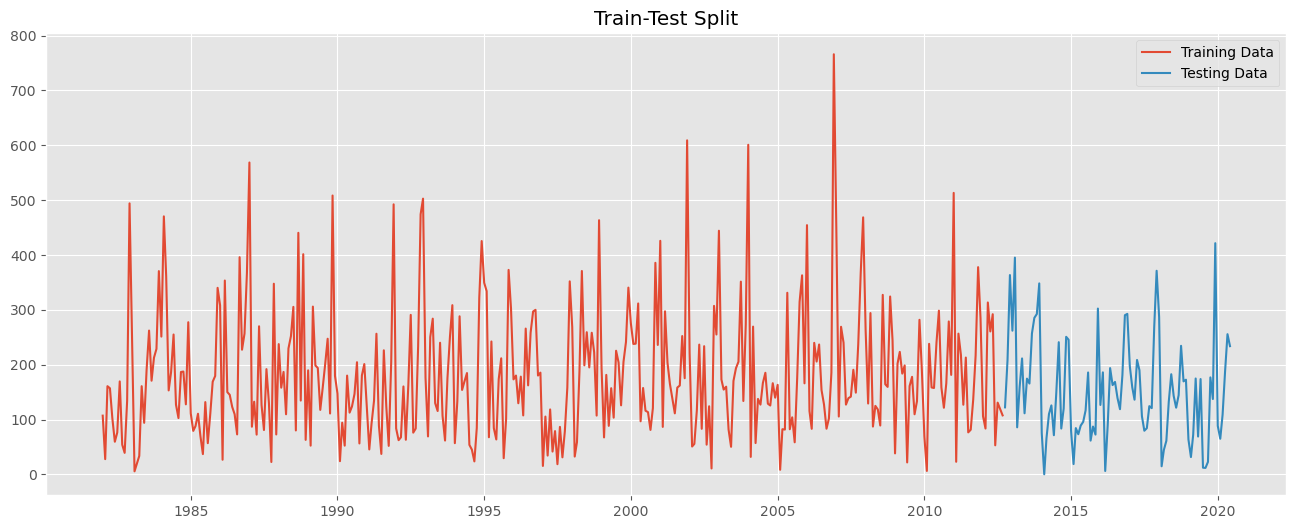

In [45]:
plt.figure(figsize=(16,6))

plt.plot(train, label="Training Data")

plt.plot(test, label="Testing Data")

plt.legend()

plt.title("Train-Test Split")

plt.show()

# Step 43 : Summary of Time Series Analysis

### Key Observations

- The rainfall data exhibits seasonal behavior.
- Rolling statistics provide insight into stationarity.
- The ADF test determines whether differencing is needed.
- Seasonal decomposition reveals trend and seasonal components.
- ACF and PACF plots assist in selecting SARIMA parameters.
- The dataset has been split into training and testing sets and is now ready for model development.

# Step 44 : Build the SARIMA Model

SARIMA (Seasonal AutoRegressive Integrated Moving Average) is suitable for
time series data that contains trend and seasonality.

Model Parameters

- p = 1
- d = 0
- q = 1

Seasonal Parameters

- P = 1
- D = 1
- Q = 1
- m = 12

In [46]:
# Build SARIMA Model

model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_model = model.fit()

print("SARIMA Model Built Successfully")

C:\Users\aravi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\aravi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\aravi\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA Model Built Successfully


# Step 45 : Model Summary

The summary provides

- AIC
- BIC
- Log Likelihood
- Coefficients
- Statistical Significance

In [47]:
print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                     total_rainfall   No. Observations:                  369
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood               -2087.093
Date:                            Wed, 05 Aug 2026   AIC                           4184.187
Time:                                    00:57:05   BIC                           4203.375
Sample:                                01-01-1982   HQIC                          4191.830
                                     - 09-01-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9535      0.039    -24.233      0.000      -1.031      -0.876
ma.L1          0.9218      0.054   

# Step 46 : Predict on Test Data

In [48]:
prediction = sarima_model.predict(
    start=test.index[0],
    end=test.index[-1]
)

prediction.head()

2012-10-01    153.408674
2012-11-01    272.533799
2012-12-01    312.830159
2013-01-01    257.256429
2013-02-01     97.863053
Freq: MS, Name: predicted_mean, dtype: float64

# Step 47 : Compare Actual vs Predicted Values

In [49]:
comparison = pd.DataFrame({
    "Actual": test,
    "Predicted": prediction
})

comparison.head()

,Actual,Predicted
2012-10-01,122.2,153.408674
2012-11-01,208.2,272.533799
2012-12-01,363.4,312.830159
2013-01-01,262.0,257.256429
2013-02-01,395.2,97.863053


# Step 48 : Plot Actual vs Predicted Rainfall

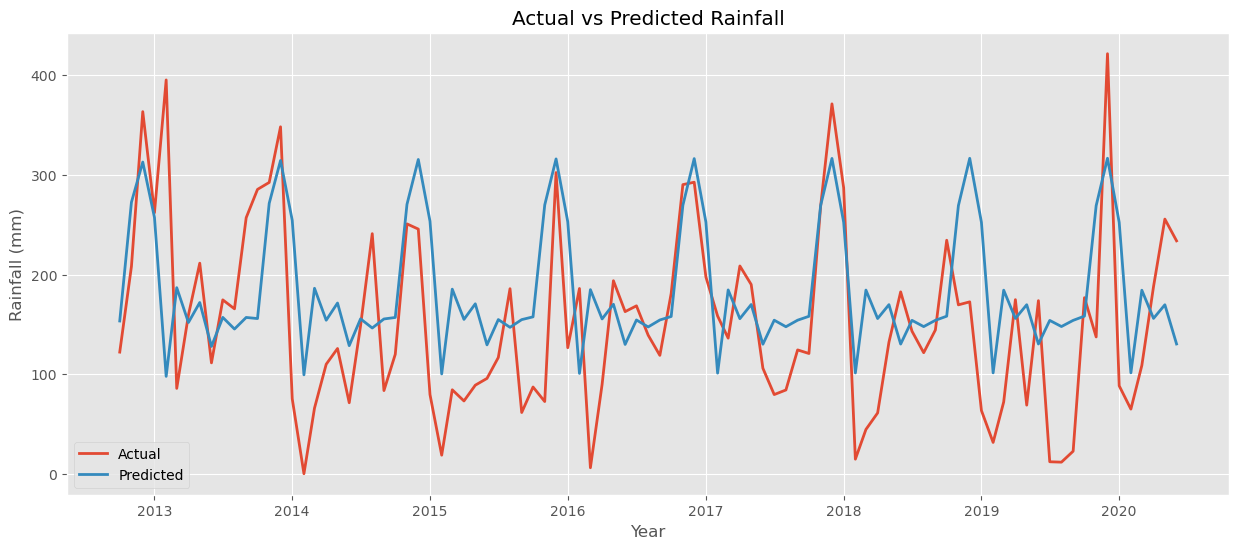

In [50]:
plt.figure(figsize=(15,6))

plt.plot(test.index,
         test,
         label="Actual",
         linewidth=2)

plt.plot(prediction.index,
         prediction,
         label="Predicted",
         linewidth=2)

plt.title("Actual vs Predicted Rainfall")

plt.xlabel("Year")

plt.ylabel("Rainfall (mm)")

plt.legend()

plt.grid(True)

plt.show()

# Step 49 : Calculate MAE

In [51]:
mae = mean_absolute_error(test, prediction)

print("Mean Absolute Error (MAE) :", round(mae,2))

Mean Absolute Error (MAE) : 69.33


# Step 50 : Calculate MSE

In [52]:
mse = mean_squared_error(test, prediction)

print("Mean Squared Error (MSE) :", round(mse,2))

Mean Squared Error (MSE) : 7656.09


# Step 51 : Calculate RMSE

In [53]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE) :", round(rmse,2))

Root Mean Squared Error (RMSE) : 87.5


# Step 52 : Forecast Next 12 Months

After evaluating the model, retrain it using the full dataset and forecast the
next 12 months.

In [54]:
final_model = SARIMAX(
    ts,
    order=(1,0,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_model = final_model.fit()

print("Final Model Ready")

C:\Users\aravi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\aravi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Final Model Ready


# Step 53 : Forecast Future Rainfall

In [55]:
forecast = final_model.forecast(steps=12)

forecast

2020-07-01    154.322449
2020-08-01    151.815576
2020-09-01    148.595853
2020-10-01    167.185090
2020-11-01    255.664991
2020-12-01    323.897320
2021-01-01    226.568684
2021-02-01    106.558587
2021-03-01    160.906498
2021-04-01    155.935712
2021-05-01    170.202996
2021-06-01    138.699582
Freq: MS, Name: predicted_mean, dtype: float64

# Step 54 : Create Forecast DataFrame

In [56]:
future_dates = pd.date_range(
    start=ts.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

forecast_df = pd.DataFrame({
    "Month": future_dates,
    "Forecasted_Rainfall": forecast.values
})

forecast_df

,Month,Forecasted_Rainfall
0,2020-07-01,154.322449
1,2020-08-01,151.815576
2,2020-09-01,148.595853
3,2020-10-01,167.185090
4,2020-11-01,255.664991
5,2020-12-01,323.897320
6,2021-01-01,226.568684
7,2021-02-01,106.558587
8,2021-03-01,160.906498
9,2021-04-01,155.935712


# Step 55 : Forecast Plot

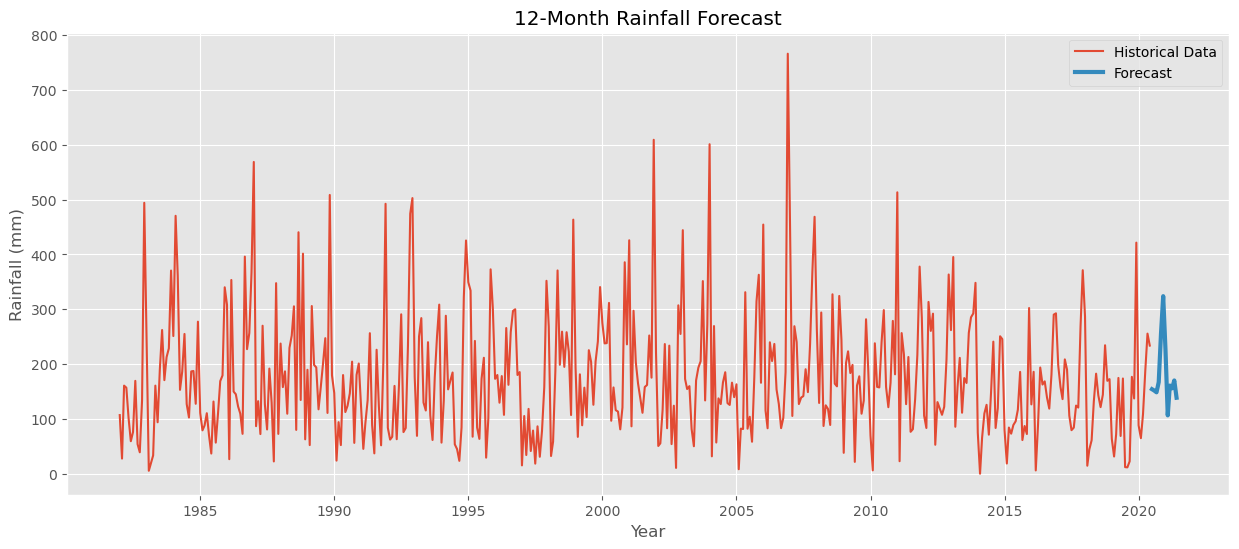

In [57]:
plt.figure(figsize=(15,6))

plt.plot(ts,
         label="Historical Data")

plt.plot(future_dates,
         forecast,
         label="Forecast",
         linewidth=3)

plt.title("12-Month Rainfall Forecast")

plt.xlabel("Year")

plt.ylabel("Rainfall (mm)")

plt.legend()

plt.grid(True)

plt.show()

# Step 56 : Forecast Table

In [58]:
forecast_df

,Month,Forecasted_Rainfall
0,2020-07-01,154.322449
1,2020-08-01,151.815576
2,2020-09-01,148.595853
3,2020-10-01,167.185090
4,2020-11-01,255.664991
5,2020-12-01,323.897320
6,2021-01-01,226.568684
7,2021-02-01,106.558587
8,2021-03-01,160.906498
9,2021-04-01,155.935712


# Step 57 : Save Forecast Results

In [59]:
forecast_df.to_csv(
    "Rainfall_Forecast_12_Months.csv",
    index=False
)

print("Forecast Saved Successfully")

Forecast Saved Successfully


# Step 58 : Forecast Highest Daily Rainfall

The project also requires forecasting the highest rainfall recorded in a day for each month.

We prepare a second SARIMA model using the `maximum_rainfall_in_a_day` series.

In [60]:
highest_series = df["maximum_rainfall_in_a_day"]

highest_model = SARIMAX(
    highest_series,
    order=(1,0,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

highest_model = highest_model.fit()

highest_forecast = highest_model.forecast(12)

highest_forecast

C:\Users\aravi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\aravi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2020-07-01    38.857445
2020-08-01    43.620689
2020-09-01    38.891641
2020-10-01    51.862151
2020-11-01    62.182000
2020-12-01    76.888627
2021-01-01    69.591201
2021-02-01    34.900771
2021-03-01    43.296263
2021-04-01    43.948938
2021-05-01    45.908091
2021-06-01    41.132246
Freq: MS, Name: predicted_mean, dtype: float64

# Step 59 : Highest Daily Rainfall Forecast Table

In [61]:
highest_forecast_df = pd.DataFrame({
    "Month": future_dates,
    "Highest_Daily_Rainfall": highest_forecast.values
})

highest_forecast_df

,Month,Highest_Daily_Rainfall
0,2020-07-01,38.857445
1,2020-08-01,43.620689
2,2020-09-01,38.891641
3,2020-10-01,51.862151
4,2020-11-01,62.182000
5,2020-12-01,76.888627
6,2021-01-01,69.591201
7,2021-02-01,34.900771
8,2021-03-01,43.296263
9,2021-04-01,43.948938


# Step 60 : Plot Highest Daily Rainfall Forecast

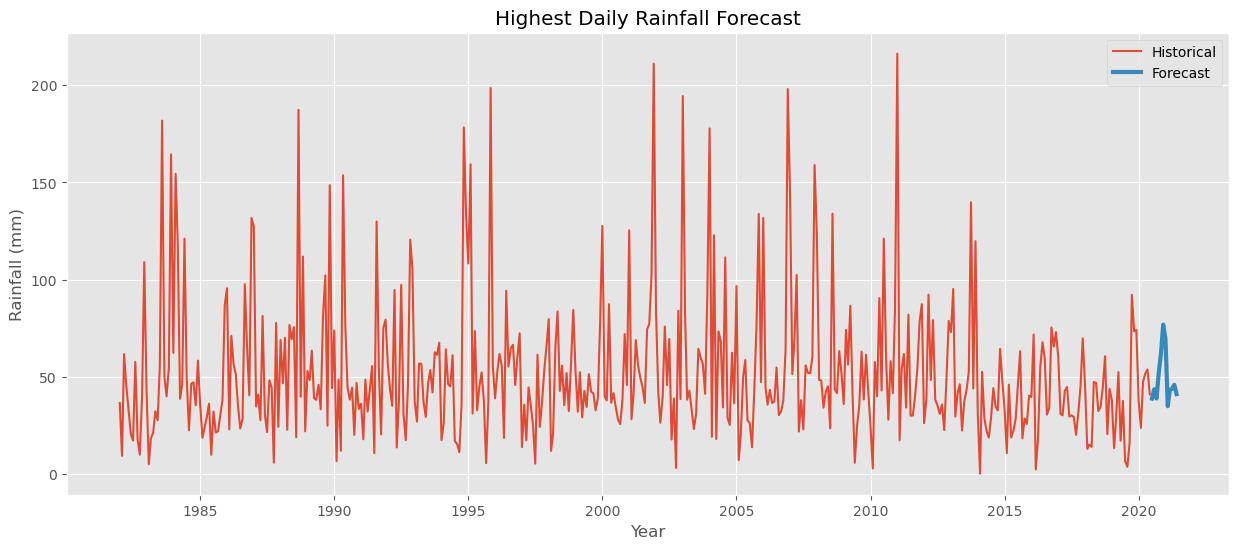

In [62]:
plt.figure(figsize=(15,6))

plt.plot(
    highest_series,
    label="Historical"
)

plt.plot(
    future_dates,
    highest_forecast,
    label="Forecast",
    linewidth=3
)

plt.title("Highest Daily Rainfall Forecast")

plt.xlabel("Year")

plt.ylabel("Rainfall (mm)")

plt.legend()

plt.grid(True)

plt.show()

In [63]:
highest_forecast_df.to_csv(
    "Highest_Daily_Rainfall_Forecast.csv",
    index=False
)

print("Highest Daily Rainfall Forecast Saved")

Highest Daily Rainfall Forecast Saved


# Step 61 : Project Summary

## Project Title

Rainfall Forecasting using Time Series Analysis

---

## Objective

The objective of this project is to analyze historical rainfall data and develop
a Time Series Forecasting model to predict rainfall for the next 12 months.

The project also forecasts the highest rainfall recorded in a day for each month.

---

## Datasets Used

1. Monthly Total Rainfall
2. Monthly Highest Daily Rainfall
3. Monthly Number of Rainy Days

Period

January 1982 – June 2020

# Step 62 : Project Workflow

The complete workflow followed in this project is shown below.

Historical Rainfall Data

↓

Data Loading

↓

Data Cleaning

↓

Exploratory Data Analysis

↓

Feature Engineering

↓

Stationarity Test

↓

Seasonal Decomposition

↓

ACF & PACF

↓

SARIMA Model

↓

Model Evaluation

↓

Forecast Next 12 Months

↓

Business Insights

# Step 64 : Model Performance

The SARIMA model was evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)

Lower values of these metrics indicate better predictive performance.

In [64]:
print("Model Performance")

print("--------------------------")

print("MAE :", round(mae,2))

print("MSE :", round(mse,2))

print("RMSE :", round(rmse,2))

Model Performance
--------------------------
MAE : 69.33
MSE : 7656.09
RMSE : 87.5


# Step 65 : Forecast Results

The SARIMA model generated

• Monthly rainfall forecast for the next 12 months.

• Highest daily rainfall forecast for the next 12 months.

These forecasts can support planning and decision-making.

In [65]:
print("Monthly Rainfall Forecast")

display(forecast_df)

print()

print("Highest Daily Rainfall Forecast")

display(highest_forecast_df)

Monthly Rainfall Forecast


,Month,Forecasted_Rainfall
0,2020-07-01,154.322449
1,2020-08-01,151.815576
2,2020-09-01,148.595853
3,2020-10-01,167.185090
4,2020-11-01,255.664991
5,2020-12-01,323.897320
6,2021-01-01,226.568684
7,2021-02-01,106.558587
8,2021-03-01,160.906498
9,2021-04-01,155.935712



Highest Daily Rainfall Forecast


,Month,Highest_Daily_Rainfall
0,2020-07-01,38.857445
1,2020-08-01,43.620689
2,2020-09-01,38.891641
3,2020-10-01,51.862151
4,2020-11-01,62.182000
5,2020-12-01,76.888627
6,2021-01-01,69.591201
7,2021-02-01,34.900771
8,2021-03-01,43.296263
9,2021-04-01,43.948938


# Step 66 : Conclusion

This project successfully analyzed historical rainfall data and built a Seasonal ARIMA (SARIMA) model for forecasting.

The workflow included:

- Data collection
- Data preprocessing
- Exploratory Data Analysis
- Time Series Analysis
- Stationarity Testing
- Seasonal Decomposition
- Model Development
- Model Evaluation
- Forecast Generation

The model generated forecasts for monthly rainfall and highest daily rainfall, demonstrating how historical time series data can be used to estimate future rainfall trends.